# Duration Times Spread

*Dts (Duration Times Spread): A new measure of spread exposure in credit portfolios*, Arik Ben Dor, Lev Dynkin, Jay Hyman, Patrick Houweling,
Erik van Leeuwen, and Olaf Penninga

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score

# Path Management and Global Variables

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
vol_renamer_ = {
    "abs_vol": r"$D \sigma_{abs}$",
    "rel_vol": r"$D s \sigma_{res}$"}

endog_renamer = {
    "alpha_j"  : r"$\alpha_J$",
    "count_val": r"$n$",	
    "t_stat"   : r"$t$-stat",	
    "r2"       : r"$R^2$"}

param_renamer_ = {
    "const": r"$\alpha$",
    "oas"  : r"$\beta$"}

ols_renamer_ = {
    "param_val": "Coeff",
    "t_value"  : r"$t$-value",
    "p_value"  : r"$p$-value"}

model_renamer_ = {
    "comb_model"     : "Combined",
    "comb_norm_model": "Combo Norm",
    "par_model"      : "Parallel",
    "rel_model"      : "Relative"} 

comp_renamer_ = {
    "idio_comp": "Idiosyncratic Component",
    "sys_comp" : "Systemic Component"}

cred_path = os.path.join(data_path, "CreditTickers.xlsx")
plot_renamer_ = (pd
    .read_excel(io = cred_path)
    .assign(ticker = lambda x: x.ticker.str.split(" ").str[0])
    .set_index("ticker")
    [["plot_name"]]
    .plot_name
    .to_dict())

renamer = {**vol_renamer_, **endog_renamer, **param_renamer_, **ols_renamer_, **model_renamer_, **plot_renamer_, **comp_renamer_}

# Examining Data

Start by examining the OAS of the data, for now we are going to use US-only data. 

In [4]:
path       = os.path.join(data_path, "CreditTickers.xlsx")
df_tickers = (pd
    .read_excel(io = path)
    .loc[lambda x: (x.region == "US") & (x.credit_type == "credit")])

tickers = (df_tickers
    .ticker
    .drop_duplicates()
    .sort_values()
    .to_list())

In [5]:
path   = os.path.join(data_path, "SlicedCreditData.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .loc[lambda x: x.security.isin(tickers)]
    .assign(security = lambda x: x.security.str.split(" ").str[0]))

In [6]:
start_date = (df_raw
    .pivot(index = "date", columns = "security", values = "oas")
    .reset_index()
    [["date"]]
    .assign(
        lag_date    = lambda x: x.date.shift(),
        spread_date = lambda x: (x.date - x.lag_date).dt.days)
    .loc[lambda x: x.spread_date <= 4]
    .date
    .iloc[0])

In [7]:
df_sliced = (df_raw
    .loc[lambda x: x.date >= start_date])

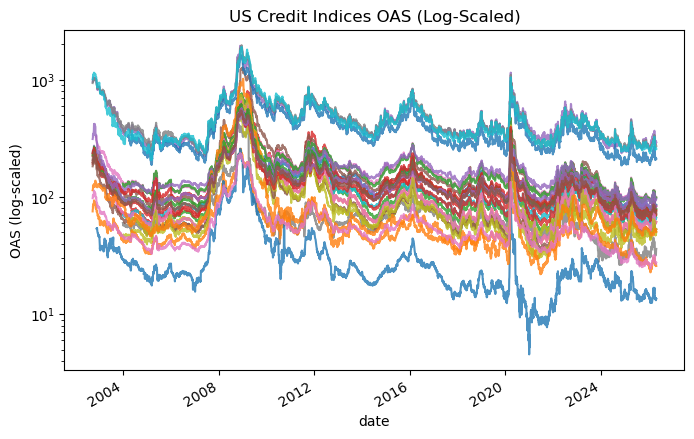

In [8]:
(df_sliced
    .loc[lambda x: x.oas != 0]
    .pivot(index = "date", columns = "security", values = "oas")
    .plot(
        figsize = (8,5),
        legend  = False,
        alpha   = 0.8,  
        logy    = True,
        ylabel  = "OAS (log-scaled)",
        title   = "US Credit Indices OAS (Log-Scaled)"))

plt.show()

# Model

Start with the two methodologies for modelling returns through the lens of duration and spread changes. Then we can calculate their respective volatility
\begin{align}
R_{spread} = 
\begin{cases}
\ -D\Delta s, & \text{Absolute} \\
\ - Ds \frac{\Delta s}{s}, & \text{Relative}
\end{cases}
\rightarrow
\sigma_{return} =
\begin{cases}
\ D \sigma_{absolute}, & \text{Absolute} \\
\ Ds \sigma_{relative}, & \text{Relative}
\end{cases}
\end{align}

In [9]:
df_oas = (df_sliced
    [["date", "security", "oas"]]
    .set_index("date"))

In [10]:
df_oas_diff = (df_oas
    .groupby(["security"])
    .apply(lambda x: x.sort_index().oas.diff())
    .to_frame(name = "oas_diff")
    .reset_index())

In [11]:
df_lag_oas = (df_oas
    .groupby("security")
    .apply(lambda x: x.sort_index().oas.shift())
    .to_frame(name = "lag_oas")
    .reset_index())

In [12]:
df_oas_prep = (df_oas_diff
    .merge(right = df_lag_oas, how = "inner", on = ["security", "date"])
    .assign(rel_diff = lambda x: x.oas_diff / x.lag_oas)
    .rename(columns = {"oas_diff": "abs_diff"})
    [["date", "security", "abs_diff", "rel_diff"]]
    .dropna())

In [13]:
num_months = 3

df_oas_tmp_vol = (df_oas_prep
    .set_index("date")
    .groupby("security")
    .apply(lambda x: x.sort_index().rolling(window = 30 * num_months).std())
    .reset_index()
    .dropna())

In [14]:
df_vol = (df_sliced
    [["date", "security", "sprd_dur", "oas"]]
    .merge(right = df_oas_tmp_vol, how = "inner", on = ["date", "security"])
    .assign(
        abs_vol = lambda x: x.abs_diff * x.sprd_dur,
        rel_vol = lambda x: x.rel_diff * x.oas * x.sprd_dur))

In [15]:
ticker_map = (df_tickers
    .dropna()
    .assign(
        ticker  = lambda x: x.ticker.str.split(" ").str[0],
        str_len = lambda x: x.plot_name.str.len())
    .loc[lambda x: x.str_len <= 4]
    .set_index("ticker")
    .plot_name
    .to_dict())

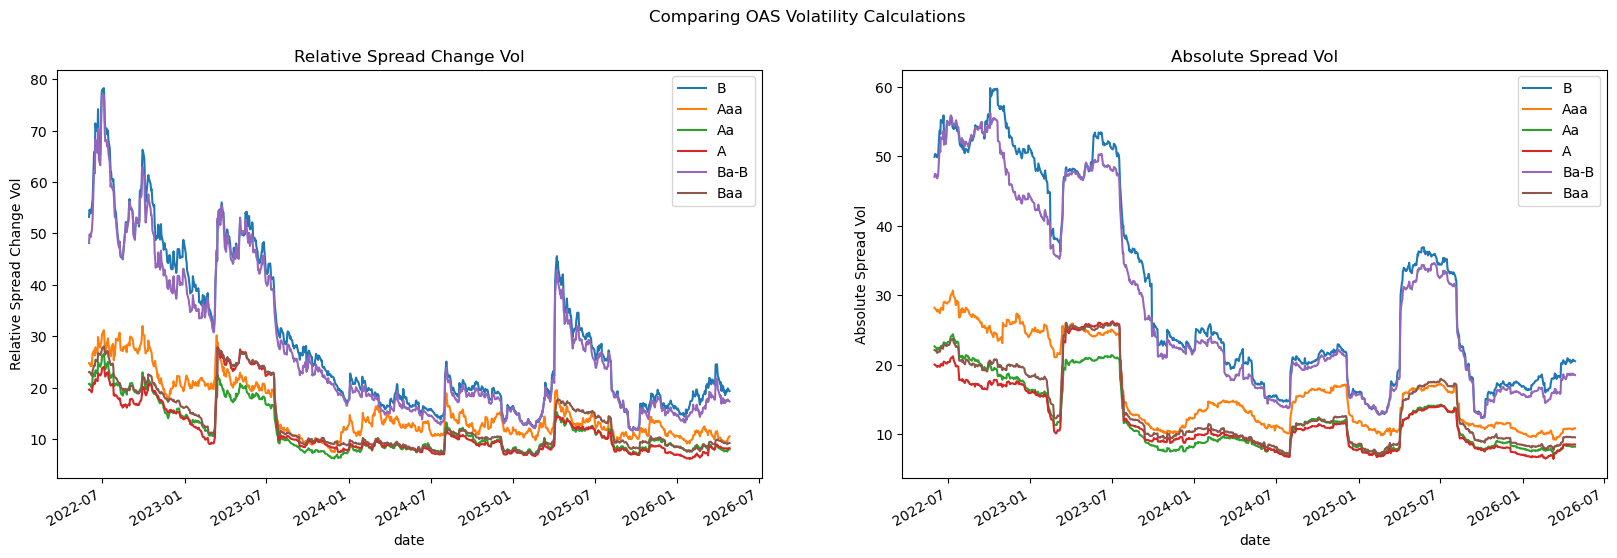

In [16]:
vol_dict  = {
    "rel_vol": "Relative Spread Change Vol", 
    "abs_vol": "Absolute Spread Vol"}

fig, axes = plt.subplots(ncols = len(vol_dict.keys()), figsize = (20,6))

for vol, ax in zip(vol_dict.keys(), axes.flatten()): 

    (df_vol
        .loc[lambda x: x.security.isin(list(ticker_map.keys()))]
        .rename(columns = {"security": ""})
        .pivot(index = "date", columns = "", values = vol)
        .rename(columns = ticker_map)
        .dropna()
        .tail(1_000)
        .plot(
            ax     = ax,
            ylabel = vol_dict[vol],
            title  = vol_dict[vol]))

fig.suptitle("Comparing OAS Volatility Calculations")
plt.show()

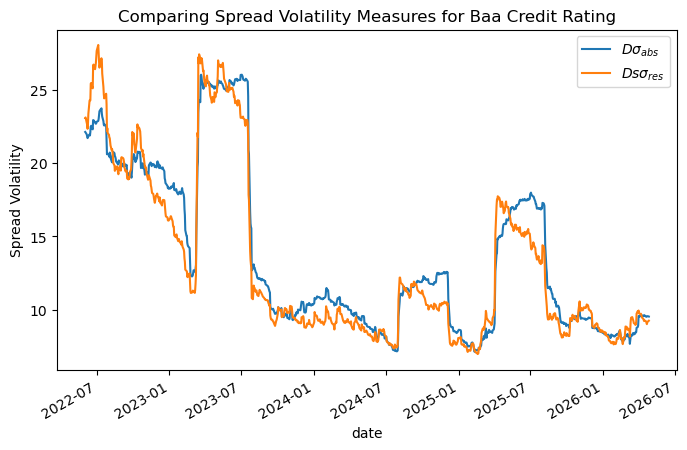

In [17]:
(df_vol
    .loc[lambda x: x.security == "LCB1TRUU"]
    .set_index("date")
    [["abs_vol", "rel_vol"]]
    .rename(columns = renamer)
    .tail(1_000)
    .plot(
        figsize = (8,5),
        ylabel  = "Spread Volatility",
        title   = "Comparing Spread Volatility Measures for Baa Credit Rating"))

plt.show()

# Dynamics of Spread Change

In [18]:
df_oas_diff = (df_sliced
    [["date", "security", "oas"]]
    .set_index("date")
    .groupby("security")
    .apply(lambda x: x.sort_index().oas.diff())
    .to_frame(name = "oas_diff")
    .reset_index())

In [19]:
df_oas_sys_diff = (df_oas_diff
    .drop(columns = ["security"])
    .groupby("date")
    .agg("mean")
    .rename(columns = {"oas_diff": "oas_sys_diff"})
    .reset_index())

df_oas_sys = (df_sliced
    [["date", "oas"]]
    .groupby("date")
    .agg("mean")
    .rename(columns = {"oas": "oas_sys"}))

In [20]:
df_setup = (df_oas_diff
    .merge(right = df_oas_sys,      how = "inner", on = ["date"])
    .merge(right = df_sliced,       how = "inner", on = ["date", "security"])
    .merge(right = df_oas_sys_diff, how = "inner", on = ["date"])
    .dropna()
    .set_index("date")
    .assign(oas_sys_rel = lambda x: x.oas_sys_diff / x.oas_sys))

We have the following models with the following attributes
\begin{align}
\begin{cases}
\textrm{Parallel Model},&                \Delta s_i = \Delta s_{J,t} + \Delta s_{i,t}^{idio}                            &\rightarrow& \Delta s_{i,t} = \alpha_{J,t} + \epsilon_{i,t}    \\
\textrm{Relative Model},&                \Delta s_i = s_i \frac{\Delta s_J}{s_J} + \Delta s_i^{idio}                    &\rightarrow& \Delta s_{i,t} = \beta_{J,t} \cdot s_{i,t} + \epsilon_{i,t}   \\
\textrm{Combined Model},&                \Delta s_i = s_i \frac{\Delta s_J}{s_J} + \Delta s_i^{idio}                    &\rightarrow& \Delta s_{i,t} = \alpha_{J,t} + \beta_{J,t} \cdot s_{i,t} + \epsilon_{i,t} \\
\textrm{... w Norm Spread},& \Delta s_i = (s_i -\bar{s_j}) \cdot \frac{\Delta s_J}{s_J} + \Delta s_i^{idio}  &\rightarrow& \Delta s_{i,t} = \bar{\alpha}_{J,t} + \beta_{J,t} \cdot (s_{i,t} - \bar{s}_{J,t})+ \epsilon_{i,t}
\end{cases}
\end{align}

In [21]:
def _get_models(df_tmp: pd.DataFrame) -> dict:
    
    par_model = (sm
        .OLS(
            endog = df_tmp.oas_diff,
            exog  = np.ones(len(df_tmp)))
        .fit())
    
    rel_model = (sm
        .OLS(
            endog = df_tmp.oas_diff,
            exog  = df_tmp.oas)
        .fit())
    
    comb_model = (sm
        .OLS(
            endog = df_tmp.oas_diff,
            exog  = sm.add_constant(df_tmp[["oas"]]))
        .fit())

    df_comb = (df_tmp
        .assign(oas = lambda x: x.oas - x.oas_sys))
    
    comb_norm_model = (sm
        .OLS(
            endog = df_comb["oas_diff"],
            exog  = sm.add_constant(df_comb["oas"]))
        .fit())
    
    model = {
        "par_model"      : par_model,
        "rel_model"      : rel_model,
        "comb_model"     : comb_model,
        "comb_norm_model": comb_norm_model}

    return model

securitys  = df_setup.security.drop_duplicates().sort_values().to_list()
ols_models = {}

for security in securitys: 

    df_tmp               = df_setup.loc[lambda x: x.security == security]
    ols_models[security] = _get_models(df_tmp)

In [22]:
def _get_ols_params(tmp_model) -> pd.DataFrame: 

    df_param = (tmp_model
        .params
        .to_frame(name = "param_val")
        .reset_index())

    df_tvalue = (tmp_model
        .tvalues
        .to_frame(name = "t_value")
        .reset_index())

    df_pvalue = (tmp_model
        .pvalues
        .to_frame(name = "p_value")
        .reset_index())

    df_out = (df_param
        .merge(right = df_tvalue, how = "inner", on = ["index"])
        .merge(right = df_pvalue, how = "inner", on = ["index"]))

    return df_out

tickers        = list(ols_models.keys())
df_param_lists = []

for ticker in tickers: 

    tmp_models  = ols_models[ticker]
    model_names = list(tmp_models.keys())

    model_lists = ([
        _get_ols_params(tmp_models[name]).assign(name = name)
        for name in model_names])

    df_add = (pd
        .concat(model_lists)
        .assign(ticker = ticker))

    df_param_lists.append(df_add)

In [23]:
df_params = (pd
    .concat(df_param_lists)
    .rename(columns = {"index": "param"})
    .assign(param = lambda x: x.param.astype(str)))

In [24]:
tmp_tickers = ['I08220US', 'I08219US', 'I08218US', 'I00185US', 'I09036US', 'LCB1TRUU']
display(df_params
    .loc[lambda x: x.ticker.isin(tmp_tickers)]
    .melt(id_vars = ["param", "name", "ticker"])
    .rename(columns = {"variable": ""})
    .replace(renamer)
    .pivot(index = ["ticker", "name"], columns = ["", "param"], values = "value"))

Coeff            $t$-value                $p$-value  \
param              $\alpha$   $\beta$   $\alpha$    $\beta$      $\alpha$   
ticker name                                                                 
A      Combined   -0.068380  0.000554  -1.053229   1.253545  2.922814e-01   
       Combo Norm  0.543215  0.011796   7.270958   8.295217  4.058045e-13   
       Parallel   -0.000675       NaN  -0.018733        NaN  9.850549e-01   
       Relative         NaN  0.000167        NaN   0.680019           NaN   
Aa     Combined   -0.067747  0.000764  -1.160909   1.460985  2.457282e-01   
       Combo Norm  0.489914  0.006191   6.316008   7.064709  2.890247e-10   
       Parallel    0.000447       NaN   0.012756        NaN  9.898231e-01   
       Relative         NaN  0.000278        NaN   0.887063           NaN   
Aaa    Combined   -0.275343  0.003739  -2.612972   3.257489  8.999801e-03   
       Combo Norm  0.719539  0.007553   5.715834   6.693221  1.147871e-08   
       Parallel   -0.004255       NaN  -0.065771        NaN  9.475624e-01   
       Relative         NaN  0.001370        NaN   1.945255           NaN   
B      Combined   -0.559222  0.000945  -1.623596   1.437120  1.045151e-01   
       Combo Norm -0.952196  0.002782  -2.510311   2.404709  1.208890e-02   
       Parallel   -0.112151       NaN  -0.758487        NaN  4.481893e-01   
       Relative         NaN -0.000019        NaN  -0.068225           NaN   
Ba-B   Combined   -0.517272  0.001270  -1.797676   1.931117  7.228259e-02   
       Combo Norm -0.902155  0.003969  -2.812157   3.001161  4.938283e-03   
       Parallel   -0.020622       NaN  -0.159757        NaN  8.730785e-01   
       Relative         NaN  0.000213        NaN   0.723118           NaN   
Baa    Combined   -0.093663  0.000494  -1.136103   1.223865  2.559621e-01   
       Combo Norm  0.687538 -0.070950  12.989094 -19.351603  4.959450e-38   
       Parallel   -0.005604       NaN  -0.139234        NaN  8.892700e-01   
       Relative         NaN  0.000094        NaN   0.475912           NaN   

                                 
param                   $\beta$  
ticker name                      
A      Combined    2.100597e-01  
       Combo Norm  1.344018e-16  
       Parallel             NaN  
       Relative    4.965208e-01  
Aa     Combined    1.440756e-01  
       Combo Norm  1.805004e-12  
       Parallel             NaN  
       Relative    3.750830e-01  
Aaa    Combined    1.130708e-03  
       Combo Norm  2.395405e-11  
       Parallel             NaN  
       Relative    5.179407e-02  
B      Combined    1.507365e-01  
       Combo Norm  1.621579e-02  
       Parallel             NaN  
       Relative    9.456091e-01  
Ba-B   Combined    5.351930e-02  
       Combo Norm  2.701456e-03  
       Parallel             NaN  
       Relative    4.696375e-01  
Baa    Combined    2.210545e-01  
       Combo Norm  8.057593e-81  
       Parallel             NaN  
       Relative    6.341552e-01

In [25]:
df_comp_list = []
for model in ols_models.keys():

    tmp_model = ols_models[model]["comb_model"]
    
    df_sys = (tmp_model
        .fittedvalues
        .to_frame(name = "sys_comp"))

    df_idio = (tmp_model
        .resid
        .to_frame(name = "idio_comp"))

    df_add =(df_sys
        .merge(right = df_idio, how = "inner", on = ["date"])
        .assign(benchmark = model))
    
    df_comp_list.append(df_add)

df_comps = pd.concat(df_comp_list)

In [26]:
df_avg_oas = (df_oas
    .reset_index(drop = True)
    .groupby("security")
    .agg("mean")
    .rename(columns = {"oas": "avg_oas"}))

In [27]:
df_plot = (df_comps
    .reset_index(drop = True)
    .groupby("benchmark")
    .agg("std")
    .reset_index()
    .rename(columns = {"benchmark": "security"})
    .merge(right = df_avg_oas, how = "inner", on = ["security"])
    .melt(id_vars = ["security", "avg_oas"]))

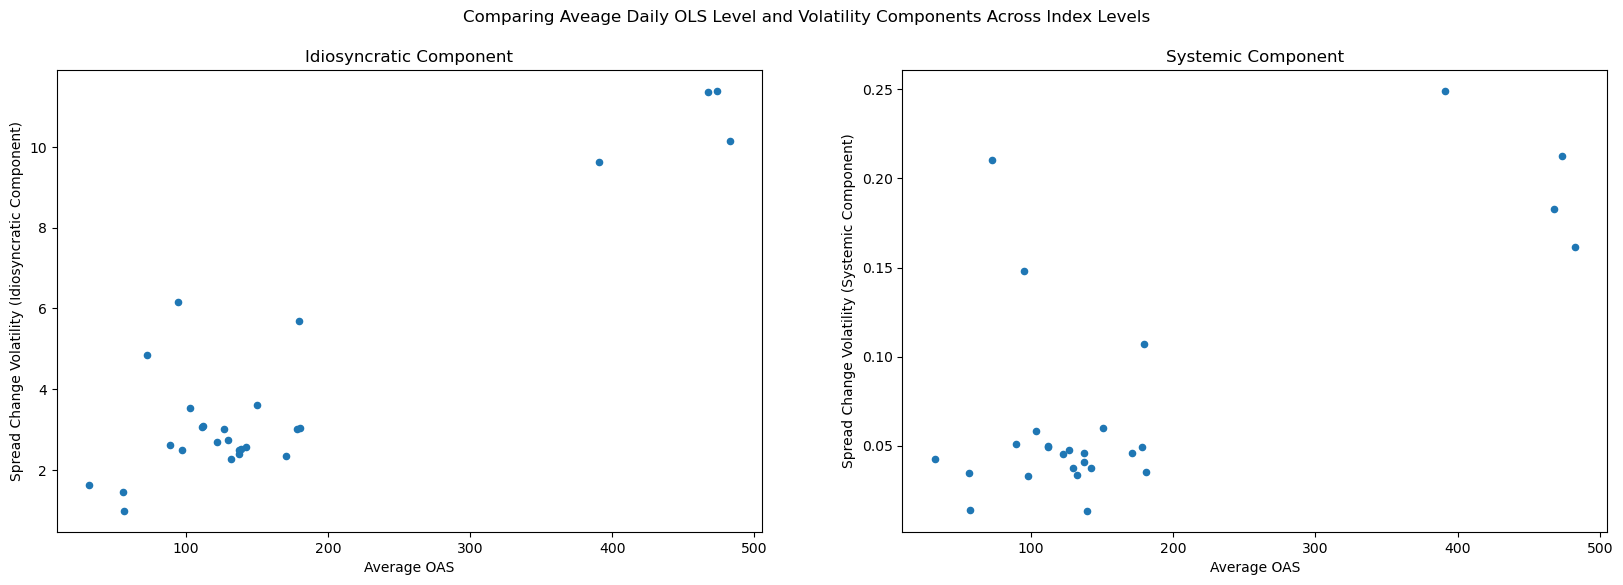

In [28]:
comps     = df_plot.variable.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(comps), figsize = (20,6))

for comp, ax in zip(comps, axes.flatten()): 

    (df_plot
        .loc[lambda x: x.variable == comp]
        .plot(
            kind   = "scatter", 
            x      = "avg_oas", 
            y      = "value",
            ax     = ax,
            title  = renamer[comp],
            xlabel = "Average OAS",
            ylabel = "Spread Change Volatility (" + renamer[comp] + ")"))

fig.suptitle("Comparing Aveage Daily OLS Level and Volatility Components Across Index Levels")
plt.show()

# Comparing the excess returns volatility forecast

Using the proportional model we can express the spreads into their systemtic and idiosyncratic drivers. Start by getting 
\begin{align}
\Delta s_{J,t} &= \beta_J \cdot s_{J,t} +s_{J,t}^{\textrm{idio}} \\ 
               &\sim \beta_J \cdot s_{J,t}   
\end{align}
When we express changes in absolute spread $\left(\Delta s_{i,t} \right)$ as changes in relative spread $\left(\frac{\Delta s_{i,t}}{s_{i,t}} \right)$ the we get the following proportionality
\begin{align}
\frac{\Delta s_{J,t}}{s_{J,t}} &= \beta_J +  s_{J,t}^{\textrm{idio}} \\
                               &\sim \beta_J
\end{align}
Therefore when we take their corresponding volatilities
\begin{align}
\sigma \left(\frac{\Delta s_{J,t}}{s_{J,t}} \right) &= \sigma(\beta_J) = \theta \\
\sigma \left(\Delta s_J \right)                     &= \bar{s}_J \sigma(\beta_J)
\end{align}
They call $\bar{s}_J$ some time-weighted standard deviation. We'll also use the notation of $\sum_{i \in J} D_i = D_J$

\begin{align}
\textrm{vol ratio}_{J,t} &= \frac{\sigma_t \left(\frac{\Delta s_J}{s_J} \right) \cdot \sum_{i \in J} D_{i,t} \cdot s_{i,t}}{\sigma(\Delta s_J) \cdot \sum_{i \in J} D_{i,t}} \\
                         &= \frac{\theta \cdot \sum_{i\in J}D_{i,t} \cdot s_{i,t}}{\theta \cdot \bar{s}_{J,t} \cdot D_{J,t}}
\end{align}

knowing that $s_{i,t} = s_J + s_i^{idio}$ and roughly $s_{i,t} \sim s_J$ we get 
\begin{align}
\textrm{vol ratio}_{J,t} &= \frac{\theta \cdot \sum_{i\in J}D_{i,t} \cdot s_{J,t}}{\theta \cdot \bar{s}_{J,t} \cdot D_{J,t}} \\
                         &= \frac{\theta \cdot s_{J,t} \cdot \sum_{i\in J}D_{i,t}}{\theta \cdot \bar{s}_{J,t} \cdot D_{J,t}} \\
                         &= \frac{\theta \cdot s_{J,t} \cdot D_J}{\theta \cdot \bar{s}_{J,t} \cdot D_{J,t}} \\
                         &= \frac{s_{J,t} \cdot D_{J,t}}{\bar{s}_{J,t} \cdot D_{J,t}} \\
                         &= \frac{s_{J,t}}{\bar{s}_{J,t}} 
\end{align}